In [1]:
folder_of_data = "/data001/projects/ising/energy_decomposition"

# prepare notebook
pip install librarys you need right below

In [2]:
!pip3 install matplotlib
!pip3 install pandas

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [63]:
import matplotlib.pyplot as plt
import pandas as pd
import os

# load files

In [23]:
def find_file_recursive(root_folder, file_name, current_depth=0, max_depth=None, verbose=True):
    """
    Recursively search for a file in all subdirectories
    
    Args:
        root_folder (str): Path to start searching from
        file_name (str): Name of the file to look for
        current_depth (int): Current recursion depth (for display purposes)
        max_depth (int): Maximum depth to search (None for unlimited)
        verbose (bool): Whether to print detailed output
    
    Returns:
        list: List of paths where the file was found
    """
    found_paths = []
    indent = "  " * current_depth
    
    # Check if we've reached max depth
    if max_depth is not None and current_depth > max_depth:
        return found_paths
    
    # Normalize the path to handle different path separators
    root_folder = os.path.normpath(root_folder)
    
    # Check if the folder exists and is accessible
    if not os.path.exists(root_folder):
        if verbose:
            print(f"{indent}❌ Folder does not exist: {root_folder}")
        return found_paths
    
    if not os.path.isdir(root_folder):
        if verbose:
            print(f"{indent}❌ Not a directory: {root_folder}")
        return found_paths
    
    try:
        items = os.listdir(root_folder)
    except PermissionError:
        if verbose:
            print(f"{indent}❌ Permission denied: {root_folder}")
        return found_paths
    except Exception as e:
        if verbose:
            print(f"{indent}❌ Error accessing {root_folder}: {e}")
        return found_paths
    
    if verbose:
        print(f"{indent}📁 Searching in: {root_folder}")
    
    # Check if the file exists in current directory
    file_path = os.path.join(root_folder, file_name)
    if os.path.isfile(file_path):  # Use isfile instead of exists to ensure it's a file
        if verbose:
            print(f"{indent}  ✅ Found '{file_name}'")
        found_paths.append(file_path)
    else:
        if verbose:
            print(f"{indent}  ❌ '{file_name}' not found")
    
    # Recursively search in subdirectories
    subdirs = []
    for item in items:
        item_path = os.path.join(root_folder, item)
        if os.path.isdir(item_path):
            subdirs.append(item_path)
    
    if verbose and subdirs:
        print(f"{indent}  📂 Found {len(subdirs)} subdirectories")
    
    for subdir in subdirs:
        try:
            subfolder_results = find_file_recursive(subdir, file_name, current_depth + 1, max_depth, verbose)
            found_paths.extend(subfolder_results)
        except Exception as e:
            if verbose:
                print(f"{indent}  ❌ Error processing {subdir}: {e}")
    
    return found_paths

In [24]:
def extract_results_folder(file_path):
    """
    Extract the folder name that ends with '_results' from a file path
    
    Args:
        file_path (str): Full path to a file
        
    Returns:
        str: The folder name ending with '_results', or None if not found
    """
    # Split the path into components
    path_parts = file_path.split(os.sep)
    
    # Look for a folder that ends with '_results'
    for part in path_parts:
        if part.endswith('_results'):
            return part
    
    return None

In [25]:
def ensure_directory_exists(directory_path):
    """
    Check if a directory exists and create it (including all parent directories) if it doesn't.
    
    Args:
        directory_path (str): Path to the directory to check/create
    
    Returns:
        bool: True if directory exists or was created successfully, False if creation failed
    """
    try:
        os.makedirs(directory_path, exist_ok=True)
        return True
    except Exception as e:
        print(f"Error creating directory '{directory_path}': {e}")
        return False

# find all reaches associated data

In [26]:
# review files of path saved in folder_of_data variables
# not all mice have full data, still working on incomplete mice
# This will help you select which csv in the path to use
all_reach_states = find_file_recursive(folder_of_data, "per_reach_state.csv")

📁 Searching in: /data001/projects/ising/energy_decomposition
  ❌ 'per_reach_state.csv' not found
  📂 Found 23 subdirectories
  📁 Searching in: /data001/projects/ising/energy_decomposition/210421_results
    ❌ 'per_reach_state.csv' not found
    📂 Found 1 subdirectories
    📁 Searching in: /data001/projects/ising/energy_decomposition/210421_results/210421_rep1
      ❌ 'per_reach_state.csv' not found
      📂 Found 4 subdirectories
      📁 Searching in: /data001/projects/ising/energy_decomposition/210421_results/210421_rep1/begin_reach
        ❌ 'per_reach_state.csv' not found
      📁 Searching in: /data001/projects/ising/energy_decomposition/210421_results/210421_rep1/mid_reach
        ❌ 'per_reach_state.csv' not found
      📁 Searching in: /data001/projects/ising/energy_decomposition/210421_results/210421_rep1/post_reach
        ❌ 'per_reach_state.csv' not found
      📁 Searching in: /data001/projects/ising/energy_decomposition/210421_results/210421_rep1/full_reach
        ❌ 'per_reach_

## Idenitify Headers
Below is line of code that when run will show you the dataframe of one of the files that were recursively gathered.  

In [48]:
print("Columns: ")
print("- "+"\n- ".join(pd.read_csv(all_reach_states[0]).columns))
pd.read_csv(all_reach_states[0])

Columns: 
- reach_idx
- stim
- x
- y
- z
- firing_rate
- energy
- j
- h


,reach_idx,stim,x,y,z,firing_rate,energy,j,h
0,0,0,0.026840,0.118307,0.811070,0.133333,-0.030509,0.000000,0.030509
1,0,0,0.026830,0.118189,0.811066,0.142857,-0.010001,0.000000,0.010001
2,0,0,0.026794,0.118156,0.811135,0.125000,0.218246,0.000000,-0.218246
3,0,0,0.026739,0.118220,0.811268,0.133333,-0.000000,0.000000,0.000000
4,0,0,0.026693,0.118371,0.811452,0.120000,0.218246,0.000000,-0.218246
...,...,...,...,...,...,...,...,...,...
15495,19,2,0.044681,0.040594,0.858180,0.420000,0.217441,0.227199,-0.444641
15496,19,2,0.044708,0.040685,0.858544,0.466667,0.675992,0.000000,-0.675992
15497,19,2,0.044718,0.040825,0.858786,0.425000,0.217441,0.227199,-0.444641
15498,19,2,0.044711,0.040986,0.858941,0.400000,0.414794,0.060355,-0.475149


# information about the data structure
Each file will have the mouse id in its name, code below is already provided to access this idea. Here is the line that does it.

```python
mouse_id = extract_results_folder(reach).split("_")[0]
```

Below is a skeleton function I have wrote to allow easy access to the data in the csv per mouse.
feel free to alter the code below in a seperate notebook how every you want to complete an experiment.
this could include creating global arrays or extra variable to track metrics.

```python
'''
< Put code below here to analyzing reaches>
'''
 # Core code here
'''
</ Code above here>
'''
```

A good start to adding logic per reach in a stim is seen as above. Please add the core of you analysis between these tags.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
# import ipywidgets as widgets
from IPython.display import Image


find_max_idx = lambda list_: [i for i, x in enumerate(list_) if x == max(list_)]
find_min_idx = lambda list_: [i for i, x in enumerate(list_) if x == min(list_)]


def run_experiment(df, output_dir, mouse_id="", title_prefix="", show_mid_point=True):

    results = []
    current_reach_analyized = set()
    try:
        temp_current = pd.read_csv(output_dir + "/temp_store.csv")
        results = temp_current.to_dict('records')

        for r in results:
            current_reach_analyized.add(f"{r['stim']}_{r['reach_idx']}")
            
        
    except:
        print("NO temp created")
    
    unique_stims = df['stim'].unique()
    unique_reaches = df['reach_idx'].unique()
    
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)

    
    
    # Plot for each stimulus
    for stim in unique_stims:
        stim_data = df[df['stim'] == stim]
        unique_reaches_stim = stim_data['reach_idx'].unique()
        
        # Iterate over reach per stim
        for reach_idx in unique_reaches_stim:    
            reach_data = stim_data[stim_data['reach_idx'] == reach_idx]

            # check reach hasen't already been analyzed 
            if  reach_data.empty or f"{stim}_{reach_idx}" in current_reach_analyized:
                continue

            # stim - current stim [0,1,2]
            # reach_idx - index of reach in stim - good for indexing when including other dataframe together
            # reach_data - pd.dataframe scoped to only a certain reach in stim
            # mouse_id - the current id of the mouse
            '''
            < Put code below here to analyzing reaches>
            '''

            # Assume we have time column for defining ranges
            x1 = 386 # 350
            x2 = 412 # 450
             
            # parse out range
            reach_data_sliced = reach_data.iloc[x1:x2] 

            range_ = np.arange(0, x2-x1, 1)
            
            # example of grabbing max velocity idx
            x_data = reach_data_sliced['x'].values
            velocity_x = np.gradient(x_data)

            e_data = reach_data_sliced['energy'].values
            fr_data = reach_data_sliced['firing_rate'].values

            print(f"Processing [{stim}_{reach_idx}]")

            
            # velocity
            v_max_idx = find_max_idx(velocity_x)
            v_min_idx = find_min_idx(velocity_x)
            
            fig, ax = plt.subplots(figsize=(30, 6))
            ax.set_title("Velocity over time (x)")
            ax.plot(velocity_x)
            ax.grid(True)
            ax.set_xticks(range_)

            for _max_idx in v_max_idx:
                plt.plot([_max_idx,_max_idx], [0,max(velocity_x)],c='b')

            for _min_idx in v_min_idx:
                plt.plot([_min_idx,_min_idx], [min(velocity_x),0],c='r')
            
            plt.show()

            print(f"max_v {v_max_idx}")
            print(f"min_v {v_min_idx}")
            
            input_max_velocity = ""#input("idx of max velocity: ")
            input_min_velocity = ""#input("idx of min velocity: ")

            if input_max_velocity == "":
                input_max_velocity = ",".join([str(t) for t in v_max_idx])

            if input_min_velocity == "":
                input_min_velocity = ",".join([str(t) for t in v_min_idx])
            
            clear_output(wait=True)

            
            # energy
            e_max_idx = find_max_idx(e_data)
            e_min_idx = find_min_idx(e_data)
            
            fig, ax = plt.subplots(figsize=(30, 6))
            ax.set_title("energy over time")
            ax.plot(e_data)
            ax.grid(True)
            ax.set_xticks(range_)

            for _max_idx in e_max_idx:
                plt.plot([_max_idx,_max_idx], [0,max(e_data)],c='b')

            for _min_idx in e_min_idx:
                plt.plot([_min_idx,_min_idx], [min(e_data),0],c='r')
            
            plt.show()

            print(f"max_e {e_max_idx}")
            print(f"min_e {e_min_idx}")
            
            input_max_e = ""#input("idx of max energy: ")
            input_min_e = ""#input("idx of min energy: ")

            if input_max_e == "":
                input_max_e = ",".join([str(t) for t in e_max_idx])

            if input_min_e == "":
                input_min_e = ",".join([str(t) for t in e_min_idx])
            
            clear_output(wait=True)

            
            # fr
            fr_max_idx = find_max_idx(fr_data)
            fr_min_idx = find_min_idx(fr_data)
            
            fig, ax = plt.subplots(figsize=(30, 6))
            ax.set_title("fr over time")
            ax.plot(fr_data)
            ax.grid(True)
            ax.set_xticks(range_)

            for _max_idx in fr_max_idx:
                plt.plot([_max_idx,_max_idx], [0,max(fr_data)],c='b')

            for _min_idx in fr_min_idx:
                plt.plot([_min_idx,_min_idx], [min(fr_data),0],c='r')
            
            plt.show()

            print(f"max_fr {fr_max_idx}")
            print(f"min_fr {fr_min_idx}")
            
            input_max_fr = ""#input("idx of max fr_data: ")
            input_min_fr = ""#input("idx of min fr_data: ")

            
            if input_max_fr == "":
                input_max_fr = ",".join([str(t) for t in fr_max_idx])

            if input_min_fr == "":
                input_min_fr = ",".join([str(t) for t in fr_min_idx])
            
            result = {
                'mouse_id': mouse_id,
                'stim': stim,
                'reach_idx': reach_idx,
                'max_velocity_idx':input_max_velocity,
                'min_velocity_idx': input_min_velocity,
                'max_energy_idx': input_max_e,
                'min_energy_idx': input_min_e,
                'max_fr_idx': input_max_fr,
                'min_fr_idx': input_min_fr,
            }

            results += [result]
            
            pd.DataFrame(results).to_csv(output_dir + "/temp_store.csv")
            current_reach_analyized.add(f"{stim}_{reach_idx}")
            clear_output(wait=True)
            
            '''
            </ Code above here>
            '''

    print(f"{mouse_id} completed!")
    return results # - empty array currently, write the core logic of the analysis and populate the results array
                   # PLEASE only return list of dict, then it will be saved later when running 
        
    

In [10]:

results = []
for reach in all_reach_states:
    
    if not "full_reach" in reach:
        continue

    # get mouse id for file found in recusive search above
    mouse_id = extract_results_folder(reach).split("_")[0]
    print(f"Mouse ID: {mouse_id}")

    # pull the reach data into memory
    reach_data = pd.read_csv(reach)

    # construct directory for outputing results per mouse
    all_reach_output_dir = output_dir + f"/{mouse_id}"
    ensure_directory_exists(all_reach_output_dir)

    results += run_experiment(reach_data.reset_index(), all_reach_output_dir, mouse_id = mouse_id, title_prefix=f"{mouse_id}")
            


Mouse ID: 210423


NameError: name 'output_dir' is not defined

In [7]:
# please make the subdir your name or something to seperate the experiment from others
username = "enserrog" # - example mine would be enserrog
output_dir = f"/data001/projects/ising/energy_decomposition_outputs/{username}/hand_review_smaller_window" # hand_review_smaller_window

In [32]:
# Alter the directory to where the results should be saved to as a csv
# == save results #
# pd.DataFrame(results).to_csv(f"/data001/projects/ising/energy_decomposition_outputs/{username}/hand_review_smaller_window/max_velocity_results.csv")

In [29]:
results = pd.read_csv(f"/data001/projects/ising/energy_decomposition_outputs/{username}/hand_review_smaller_window/max_velocity_results.csv").to_dict('records')

import numpy as np

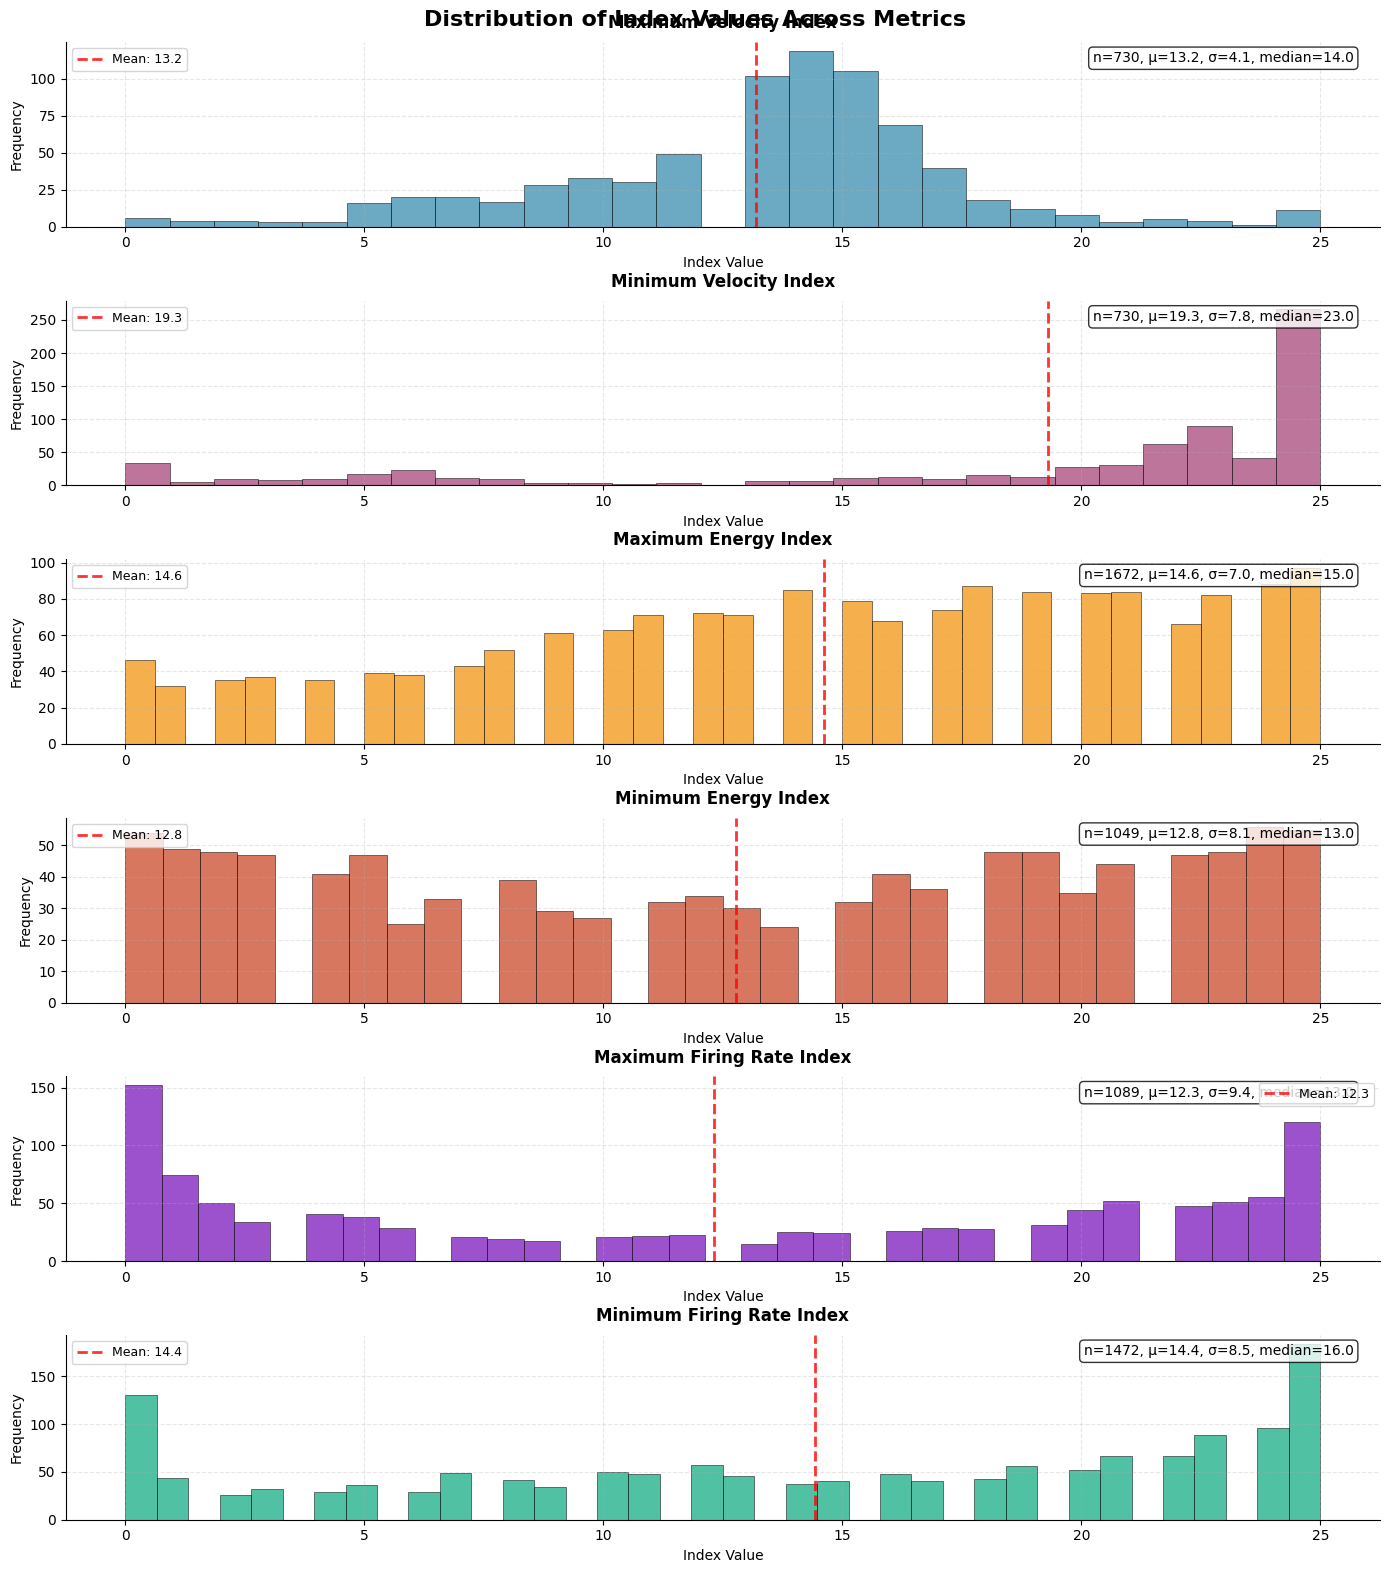

/tmp/ipykernel_1684630/3055490193.py:149: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax4.boxplot(all_data, labels=all_labels, patch_artist=True)


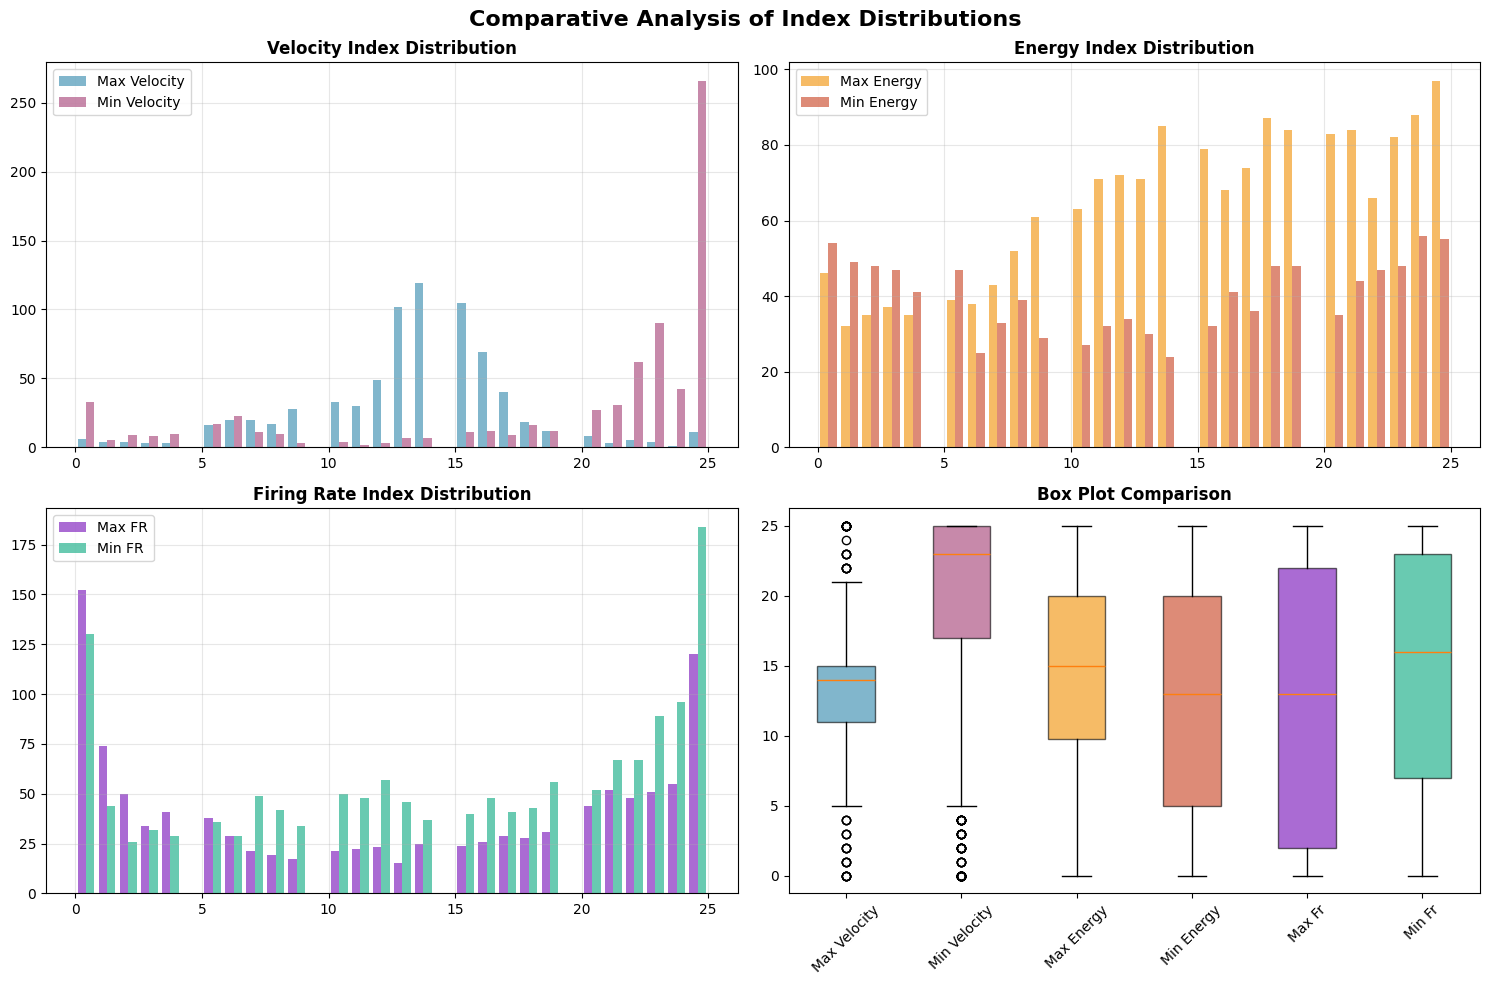

In [30]:
def extract_and_process_indices(results):
    """
    Extract and process index data from results dictionary.
    
    Args:
        results: List of dictionaries containing index data
        
    Returns:
        dict: Processed index arrays for each metric
    """
    # Initialize data structure
    index_data = {
        'max_velocity_idx': [],
        'min_velocity_idx': [],
        'max_energy_idx': [],
        'min_energy_idx': [],
        'max_fr_idx': [],
        'min_fr_idx': []
    }
    
    # Extract and flatten data
    for result in results:
        for key in index_data.keys():
            if key in result and result[key] is not None:
                # Handle both string and list inputs
                if isinstance(result[key], str):
                    values = [int(x.strip()) for x in result[key].split(",") if x.strip().isdigit()]
                elif isinstance(result[key], (list, tuple)):
                    values = [int(x) for x in result[key] if str(x).isdigit()]
                else:
                    values = [int(result[key])] if str(result[key]).isdigit() else []
                
                index_data[key].extend(values)
    
    return index_data

def create_improved_histograms(index_data, figsize=(14, 16), output_folder=""):
    """
    Create improved histogram visualizations.
    
    Args:
        index_data: Dictionary containing processed index arrays
        figsize: Figure size tuple
    """
    # Define colors and labels for better visualization
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#7209B7', '#06A77D']
    labels = {
        'max_velocity_idx': 'Maximum Velocity Index',
        'min_velocity_idx': 'Minimum Velocity Index',
        'max_energy_idx': 'Maximum Energy Index',
        'min_energy_idx': 'Minimum Energy Index',
        'max_fr_idx': 'Maximum Firing Rate Index',
        'min_fr_idx': 'Minimum Firing Rate Index'
    }
    
    fig, axes = plt.subplots(6, 1, figsize=figsize)
    fig.suptitle('Distribution of Index Values Across Metrics', fontsize=16, fontweight='bold', y=0.98)
    
    for i, (key, data) in enumerate(index_data.items()):
        if not data:  # Skip if no data
            axes[i].text(0.5, 0.5, 'No Data Available', transform=axes[i].transAxes, 
                        ha='center', va='center', fontsize=12, style='italic')
            axes[i].set_title(labels[key], fontsize=12, fontweight='bold')
            continue
        
        # Calculate optimal number of bins
        n_bins = min(50, max(10, int(np.sqrt(len(data)))))
        
        # Create histogram with improved styling
        n, bins, patches = axes[i].hist(data, bins=n_bins, color=colors[i], 
                                       alpha=0.7, edgecolor='black', linewidth=0.5)
        
        # Add statistics text
        mean_val = np.mean(data)
        std_val = np.std(data)
        median_val = np.median(data)
        
        stats_text = f'n={len(data)}, μ={mean_val:.1f}, σ={std_val:.1f}, median={median_val:.1f}'
        axes[i].text(0.98, 0.95, stats_text, transform=axes[i].transAxes, 
                    fontsize=10, ha='right', va='top', 
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
        
        # Styling improvements
        axes[i].set_title(labels[key], fontsize=12, fontweight='bold', pad=10)
        axes[i].set_xlabel('Index Value', fontsize=10)
        axes[i].set_ylabel('Frequency', fontsize=10)
        axes[i].grid(True, alpha=0.3, linestyle='--')
        axes[i].spines['top'].set_visible(False)
        axes[i].spines['right'].set_visible(False)
        
        # Add vertical line for mean
        axes[i].axvline(mean_val, color='red', linestyle='--', alpha=0.8, linewidth=2, label=f'Mean: {mean_val:.1f}')
        axes[i].legend(fontsize=9)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.96, hspace=0.4)

    if output_folder != "":
        plt.savefig(output_folder)
    
    plt.show()

def create_comparative_visualization(index_data, figsize=(15, 10), output_folder=""):
    """
    Create a comparative visualization showing all metrics together.
    
    Args:
        index_data: Dictionary containing processed index arrays
        figsize: Figure size tuple
    """
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=figsize)
    fig.suptitle('Comparative Analysis of Index Distributions', fontsize=16, fontweight='bold')
    
    # Group related metrics
    velocity_data = [index_data['max_velocity_idx'], index_data['min_velocity_idx']]
    energy_data = [index_data['max_energy_idx'], index_data['min_energy_idx']]
    fr_data = [index_data['max_fr_idx'], index_data['min_fr_idx']]
    
    # Velocity comparison
    if any(velocity_data):
        ax1.hist(velocity_data, label=['Max Velocity', 'Min Velocity'], 
                alpha=0.6, bins=30, color=['#2E86AB', '#A23B72'])
        ax1.set_title('Velocity Index Distribution', fontweight='bold')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
    
    # Energy comparison
    if any(energy_data):
        ax2.hist(energy_data, label=['Max Energy', 'Min Energy'], 
                alpha=0.6, bins=30, color=['#F18F01', '#C73E1D'])
        ax2.set_title('Energy Index Distribution', fontweight='bold')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
    
    # Firing Rate comparison
    if any(fr_data):
        ax3.hist(fr_data, label=['Max FR', 'Min FR'], 
                alpha=0.6, bins=30, color=['#7209B7', '#06A77D'])
        ax3.set_title('Firing Rate Index Distribution', fontweight='bold')
        ax3.legend()
        ax3.grid(True, alpha=0.3)
    
    # Box plot comparison
    all_data = [data for data in index_data.values() if data]
    all_labels = [key.replace('_idx', '').replace('_', ' ').title() 
                  for key, data in index_data.items() if data]
    
    if all_data:
        bp = ax4.boxplot(all_data, labels=all_labels, patch_artist=True)
        for patch, color in zip(bp['boxes'], ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#7209B7', '#06A77D']):
            patch.set_facecolor(color)
            patch.set_alpha(0.6)
        ax4.set_title('Box Plot Comparison', fontweight='bold')
        ax4.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()

    if output_folder != "":
        plt.savefig(output_folder)
    
    plt.show()

# Process the data
processed_data = extract_and_process_indices(results)
    
# Create visualizations
create_improved_histograms(processed_data)
create_comparative_visualization(processed_data)

In [ ]:
output_folder = f"/data001/projects/ising/energy_decomposition_outputs/{username}/hand_review_smaller_window/summary"

for sessions in set([x['mouse_id'] for x in results]):
    # Process the data
    session_results = list(filter(lambda x: x['mouse_id'] == sessions, results))
    processed_data = extract_and_process_indices(session_results)
        
    # Create visualizations
    create_improved_histograms(processed_data, output_folder=f"{output_folder}/{sessions}_hist.png")
    create_comparative_visualization(processed_data, output_folder=f"{output_folder}/{sessions}_vis.png")


In [ ]:


# Process the data
processed_data = extract_and_process_indices(results)
    
# Create visualizations
create_improved_histograms(processed_data)
create_comparative_visualization(processed_data)

In [20]:
import numpy as np

firing_gradient = pd.read_csv('~/ising_EnergyOverTime/min_max_results_additions_fireGradient.csv')

# create extracted columns
firing_gradient['sliced_mouse_id'] =  firing_gradient['mouse_id'].apply(lambda x: x.split("_")[0])

# construct reach idx
firing_gradient['reach_idx'] = None


for unique_reaches in firing_gradient['sliced_mouse_id'].unique():
    for stim_idx in range(0, 3):
        
        reach_select = np.logical_and(firing_gradient['sliced_mouse_id'] == unique_reaches , firing_gradient['stim'] == stim_idx)
        num_reaches = firing_gradient.loc[reach_select].shape[0]
        
        firing_gradient.loc[reach_select, 'reach_idx'] = range(0, num_reaches)

# construct unique index
firing_gradient['unique_idx'] = firing_gradient.iloc[:].apply(lambda x: f"{x['sliced_mouse_id']}_{x['stim']}-{x['reach_idx']}", axis=1)

firing_gradient.columns

Index(['Unnamed: 0', 'mouse_id', 'stim', 'max_velocity', 'min_velocity',
       'max_velocity_idx', 'min_velocity_idx', 'max_acceleration',
       'min_acceleration', 'max_acceleration_idx', 'min_acceleration_idx',
       'max_energy', 'min_energy', 'max_energy_idx', 'min_energy_idx',
       'max_firing_rate', 'min_firing_rate', 'max_firing_idx',
       'min_firing_idx', 'firing_rate_gradient_velocity_max',
       'firing_rate_gradient_velocity_min', 'file_name', 'reach_id',
       'num_neurons', 'exlcuded_reach', 'fChR2', 'fChR5', 'fChR4', 'cChR1',
       'DJC002', 'DJC000', 'mouse_id_normalized', 'sliced_mouse_id',
       'reach_idx', 'unique_idx'],
      dtype='object')

In [21]:
mouse_session_bridge = {
   extract_results_folder(session).split("_")[0]:session for session in all_reach_states
}

In [ ]:
root_folder = f"/data001/projects/ising/energy_decomposition_outputs/{username}/hand_review_smaller_window/individual"

# analyze results
for session in all_reach_states:
    
    if not "full_reach" in session:
        continue

    # get mouse id for file found in recusive search above
    mouse_id = extract_results_folder(session).split("_")[0]
    print(f"Mouse ID: {mouse_id}")

    try:
        os.makedirs(root_folder + f"/{mouse_id}")
    except:
        print("File already exist")
    
    # pull the reach data into memory
    session_reach_data = pd.read_csv(session)
    
    for reach in filter(lambda x: x['mouse_id'] == int(mouse_id), results):
       
        reach_data = session_reach_data.loc[np.logical_and(
            session_reach_data['reach_idx'] == int(reach['reach_idx']), 
            session_reach_data['stim'] == int(reach['stim'])
        )]
        
        if reach_data.empty:
            print(f"No data found for mouse {mouse_id}, stim {reach['stim']}, reach {reach['reach_idx']}")
            continue
            
        # Apply the same slicing as in the original analysis (x1=350, x2=450)
        x1 = 386 # 350
        x2 = 412 # 450
        reach_data_sliced = reach_data.iloc[x1:x2].reset_index(drop=True)
        
        if reach_data_sliced.empty:
            print(f"No sliced data available for mouse {mouse_id}, stim {reach['stim']}, reach {reach['reach_idx']}")
            continue
        
        # Parse extreme point indices from strings
        def parse_indices(idx_string):
            if pd.isna(idx_string) or idx_string == '' or idx_string == 'nan':
                return []
            return [int(x.strip()) for x in str(idx_string).split(',') if x.strip().isdigit()]
        
        # Extract data
        x_data = reach_data_sliced['x'].values
        e_data = reach_data_sliced['energy'].values
        fr_data = reach_data_sliced['firing_rate'].values
        
        # Calculate velocity
        velocity_x = np.gradient(x_data)
        
        # Parse extreme indices
        v_max_idx = parse_indices(reach['max_velocity_idx'])
        v_min_idx = parse_indices(reach['min_velocity_idx'])
        e_max_idx = parse_indices(reach['max_energy_idx'])
        e_min_idx = parse_indices(reach['min_energy_idx'])
        fr_max_idx = parse_indices(reach['max_fr_idx'])
        fr_min_idx = parse_indices(reach['min_fr_idx'])
        
        # Create time axis
        time_axis = np.arange(len(reach_data_sliced))
        
        # Create subplots (now 4 rows to include X position)
        fig, axes = plt.subplots(4, 1, figsize=(15, 16))
        fig.suptitle(f'Mouse {mouse_id} - Stim {reach["stim"]} - Reach {reach["reach_idx"]}', 
                     fontsize=16, fontweight='bold')
        
        # Plot 1: X Position
        axes[0].plot(time_axis, x_data, 'orange', linewidth=2, label='X Position')
        axes[0].set_title('X Position over Time', fontsize=14, fontweight='bold')
        axes[0].set_ylabel('X Position', fontsize=12)
        axes[0].grid(True, alpha=0.3)
        
        # Mark velocity extremes on X position plot (since velocity is derived from X)
        for idx in v_max_idx:
            if 0 <= idx < len(x_data):
                axes[0].axvline(x=idx, color='blue', linestyle='--', alpha=0.7, linewidth=2)
                axes[0].plot(idx, x_data[idx], 'bo', markersize=8, label='Vel Max' if idx == v_max_idx[0] else "")
        
        for idx in v_min_idx:
            if 0 <= idx < len(x_data):
                axes[0].axvline(x=idx, color='red', linestyle='--', alpha=0.7, linewidth=2)
                axes[0].plot(idx, x_data[idx], 'ro', markersize=8, label='Vel Min' if idx == v_min_idx[0] else "")
        
        axes[0].legend()
        
        # Plot 2: Velocity (derived from X)
        axes[1].plot(time_axis, velocity_x, 'k-', linewidth=2, label='Velocity (X)')
        axes[1].set_title('Velocity over Time (X derivative)', fontsize=14, fontweight='bold')
        axes[1].set_ylabel('Velocity', fontsize=12)
        axes[1].grid(True, alpha=0.3)
        
        # Mark velocity extremes
        for idx in v_max_idx:
            if 0 <= idx < len(velocity_x):
                axes[1].axvline(x=idx, color='blue', linestyle='--', alpha=0.7, linewidth=2)
                axes[1].plot(idx, velocity_x[idx], 'bo', markersize=8, label='Max' if idx == v_max_idx[0] else "")
        
        for idx in v_min_idx:
            if 0 <= idx < len(velocity_x):
                axes[1].axvline(x=idx, color='red', linestyle='--', alpha=0.7, linewidth=2)
                axes[1].plot(idx, velocity_x[idx], 'ro', markersize=8, label='Min' if idx == v_min_idx[0] else "")
        
        axes[1].legend()
        
        # Plot 3: Energy
        axes[2].plot(time_axis, e_data, 'g-', linewidth=2, label='Energy')
        axes[2].set_title('Energy over Time', fontsize=14, fontweight='bold')
        axes[2].set_ylabel('Energy', fontsize=12)
        axes[2].grid(True, alpha=0.3)
        
        # Mark energy extremes
        for idx in e_max_idx:
            if 0 <= idx < len(e_data):
                axes[2].axvline(x=idx, color='blue', linestyle='--', alpha=0.7, linewidth=2)
                axes[2].plot(idx, e_data[idx], 'bo', markersize=8, label='Max' if idx == e_max_idx[0] else "")
        
        for idx in e_min_idx:
            if 0 <= idx < len(e_data):
                axes[2].axvline(x=idx, color='red', linestyle='--', alpha=0.7, linewidth=2)
                axes[2].plot(idx, e_data[idx], 'ro', markersize=8, label='Min' if idx == e_min_idx[0] else "")
        
        axes[2].legend()
        
        # Plot 4: Firing Rate
        axes[3].plot(time_axis, fr_data, 'purple', linewidth=2, label='Firing Rate')
        axes[3].set_title('Firing Rate over Time', fontsize=14, fontweight='bold')
        axes[3].set_ylabel('Firing Rate', fontsize=12)
        axes[3].set_xlabel('Time Index', fontsize=12)
        axes[3].grid(True, alpha=0.3)
        
        # Mark firing rate extremes
        for idx in fr_max_idx:
            if 0 <= idx < len(fr_data):
                axes[3].axvline(x=idx, color='blue', linestyle='--', alpha=0.7, linewidth=2)
                axes[3].plot(idx, fr_data[idx], 'bo', markersize=8, label='Max' if idx == fr_max_idx[0] else "")
        
        for idx in fr_min_idx:
            if 0 <= idx < len(fr_data):
                axes[3].axvline(x=idx, color='red', linestyle='--', alpha=0.7, linewidth=2)
                axes[3].plot(idx, fr_data[idx], 'ro', markersize=8, label='Min' if idx == fr_min_idx[0] else "")
        
        axes[3].legend()
        
        # Adjust layout
        plt.tight_layout()
        
        # Display summary
        print(f"\nAnalysis Summary for Mouse {mouse_id}, Stim {reach['stim']}, Reach {reach['reach_idx']}:")
        print(f"  Velocity - Max indices: {v_max_idx}, Min indices: {v_min_idx}")
        print(f"  Energy - Max indices: {e_max_idx}, Min indices: {e_min_idx}")
        print(f"  Firing Rate - Max indices: {fr_max_idx}, Min indices: {fr_min_idx}")
        print("-" * 60)
        
        # Show the plot
        # plt.show()
        
        # Optional: Save the figure
        plt.savefig(f'{root_folder}/{mouse_id}/reach_analysis_mouse_{mouse_id}_stim_{reach["stim"]}_reach_{reach["reach_idx"]}.png', 
                     bbox_inches='tight')

        plt.close(fig)
        
        # Clear output if needed (uncomment if you want to clear between plots)
        clear_output(wait=True)

        
print("Complete!")
        
    

In [40]:
results[0]

{'Unnamed: 0': 0,
 'mouse_id': 210423,
 'stim': 0,
 'reach_idx': 0,
 'max_velocity_idx': 11,
 'min_velocity_idx': 25,
 'max_energy_idx': '3,7,9,18',
 'min_energy_idx': '4,15,17',
 'max_fr_idx': '24,25',
 'min_fr_idx': '0,5,7,9,10,11,12,13,15,16'}

In [41]:
def pull_session_reach(mouse_id, reach_idx, stim):
    
    session = mouse_session_bridge[str(mouse_id)]
    
    # pull the reach data into memory
    session_reach_data = pd.read_csv(session)

    return session_reach_data.loc[np.logical_and(
            session_reach_data['reach_idx'] == int(reach_idx), 
            session_reach_data['stim'] == int(stim)
        )]
    

In [42]:
def log_scoring(results, mouse_id, reach_idx, stim, energy_closest, fr_closest, fr_gradient, save_path=None):
    """
    Visualize reach data with max/min points and closest points highlighted.
    
    Parameters:
    -----------
    results : dict
        Dictionary containing previous analysis results with max/min indices
    mouse_id : int
        Mouse identifier
    reach_idx : int
        Reach index
    stim : int
        Stimulation condition
    energy_closest : int or str
        Index of closest point in energy
    fr_closest : int or str
        Index of closest point in firing rate
    save_path : str, optional
        Path to save the figure. If None, will auto-generate filename.
    """
    import matplotlib.pyplot as plt
    import numpy as np
    from IPython.display import clear_output
    import os
    
    # Helper function to parse comma-separated indices
    def parse_indices(idx_string):
        """Convert comma-separated string to list of integers."""
        if isinstance(idx_string, str) and idx_string.strip():
            return [int(x.strip()) for x in idx_string.split(',')]
        elif isinstance(idx_string, (int, float)):
            return [int(idx_string)]
        else:
            return []
    
    # Helper function to parse single index value
    def parse_single_index(idx_value):
        """Convert string or numeric to single integer, or None if invalid."""
        if idx_value is None or idx_value == '' or idx_value == 'None':
            return None
        try:
            return int(idx_value)
        except (ValueError, TypeError):
            return None
    
    # Get reach data
    reach_data = pull_session_reach(mouse_id, reach_idx, stim)
    
    # Define time range
    x1 = 386 # 350
    x2 = 412 # 450
    
    # Slice data
    reach_data_sliced = reach_data.iloc[x1:x2]
    range_ = np.arange(0, x2 - x1, 1)
    
    # Extract data
    x_data = reach_data_sliced['x'].values
    y_data = reach_data_sliced['y'].values if 'y' in reach_data_sliced.columns else None
    velocity_x = np.gradient(x_data)
    e_data = reach_data_sliced['energy'].values
    fr_data = reach_data_sliced['firing_rate'].values
    accel_data = np.gradient(velocity_x)
    
    print(f"Processing [{stim}_{reach_idx}]")
    
    # Parse max/min indices from results dictionary
    v_max_idx = parse_indices(results.get('max_velocity_idx', ''))
    v_min_idx = parse_indices(results.get('min_velocity_idx', ''))
    e_max_idx = parse_indices(results.get('max_energy_idx', ''))
    e_min_idx = parse_indices(results.get('min_energy_idx', ''))
    fr_max_idx = parse_indices(results.get('max_fr_idx', ''))
    fr_min_idx = parse_indices(results.get('min_fr_idx', ''))
    
    # Parse closest point indices (convert to int if string)
    energy_closest = parse_single_index(energy_closest)
    fr_closest = parse_single_index(fr_closest)
    
    # Create 4-panel figure
    fig, axes = plt.subplots(5, 1, figsize=(30, 20))
    fig.suptitle(f'Mouse {mouse_id} | Reach {reach_idx} | Stim {stim} - fr_grad:{round(fr_gradient,4)}', 
                 fontsize=16, fontweight='bold')

    fig.tight_layout(rect=[0, 0, 1, 0.97])
    # ==================== FIRING RATE ====================
    ax = axes[0]
    ax.set_title("Firing Rate over Time", fontsize=14, fontweight='bold')
    ax.plot(range_, fr_data, 'k-', linewidth=2, label='Firing Rate')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range_)
    
    # Max points (blue)
    for i, _max_idx in enumerate(fr_max_idx):
        ax.axvline(x=_max_idx, color='blue', linestyle='--', alpha=0.7, linewidth=1.5)
        ax.plot(_max_idx, fr_data[_max_idx], 'bo', markersize=10, 
                label='Max' if i == 0 else '')
    
    # Min points (red)
    for i, _min_idx in enumerate(fr_min_idx):
        ax.axvline(x=_min_idx, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
        ax.plot(_min_idx, fr_data[_min_idx], 'ro', markersize=10, 
                label='Min' if i == 0 else '')
    
    # Closest point (gold/yellow)
    if fr_closest is not None and 0 <= fr_closest < len(fr_data):
        ax.plot(fr_closest, fr_data[fr_closest], 'o', color='gold', 
                markersize=15, markeredgecolor='orange', markeredgewidth=2, 
                label='Closest Point', zorder=10)
        ax.axvline(x=fr_closest, color='gold', linestyle='-', linewidth=2.5, alpha=0.8)
    
    ax.set_ylabel("Firing Rate", fontsize=12)
    ax.legend(loc='upper right')
    
    # ==================== ENERGY ====================
    ax = axes[1]
    ax.set_title("Energy over Time", fontsize=14, fontweight='bold')
    ax.plot(range_, e_data, 'k-', linewidth=2, label='Energy')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range_)
    
    # Max points (blue)
    for i, _max_idx in enumerate(e_max_idx):
        ax.axvline(x=_max_idx, color='blue', linestyle='--', alpha=0.7, linewidth=1.5)
        ax.plot(_max_idx, e_data[_max_idx], 'bo', markersize=10, 
                label='Max' if i == 0 else '')
    
    # Min points (red)
    for i, _min_idx in enumerate(e_min_idx):
        ax.axvline(x=_min_idx, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
        ax.plot(_min_idx, e_data[_min_idx], 'ro', markersize=10, 
                label='Min' if i == 0 else '')
    
    # Closest point (gold/yellow)
    if energy_closest is not None and 0 <= energy_closest < len(e_data):
        ax.plot(energy_closest, e_data[energy_closest], 'o', color='gold', 
                markersize=15, markeredgecolor='orange', markeredgewidth=2, 
                label='Closest Point', zorder=10)
        ax.axvline(x=energy_closest, color='gold', linestyle='-', linewidth=2.5, alpha=0.8)
    
    ax.set_ylabel("Energy", fontsize=12)
    ax.legend(loc='upper right')
    
    # ==================== VELOCITY ====================
    ax = axes[2]
    ax.set_title("Velocity over Time (x)", fontsize=14, fontweight='bold')
    ax.plot(range_, velocity_x, 'k-', linewidth=2, label='Velocity')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range_)
    
    # Max points (blue)
    for i, _max_idx in enumerate(v_max_idx):
        ax.axvline(x=_max_idx, color='blue', linestyle='--', alpha=0.7, linewidth=1.5)
        ax.plot(_max_idx, velocity_x[_max_idx], 'bo', markersize=10, 
                label='Max' if i == 0 else '')
    
    # Min points (red)
    for i, _min_idx in enumerate(v_min_idx):
        ax.axvline(x=_min_idx, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
        ax.plot(_min_idx, velocity_x[_min_idx], 'ro', markersize=10, 
                label='Min' if i == 0 else '')
    
    ax.set_ylabel("Velocity", fontsize=12)
    ax.legend(loc='upper right')
    
    # ==================== POSITION ====================
    ax = axes[3]
    ax.set_title("Position over Time (x)", fontsize=14, fontweight='bold')
    ax.plot(range_, x_data, 'k-', linewidth=2, label='Position X')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range_)
    ax.set_xlabel("Time Index", fontsize=12)
    ax.set_ylabel("Position (x)", fontsize=12)
    ax.legend(loc='upper right')
    
    plt.tight_layout(rect=[0, 0, 1, 0.97])

    # ==================== ACCELERATION ====================
    ax = axes[4]
    ax.set_title("Acceleration over Time (x)", fontsize=14, fontweight='bold')
    ax.plot(range_, accel_data, 'k-', linewidth=2, label='Position X')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range_)
    ax.set_xlabel("Time Index", fontsize=12)
    ax.set_ylabel("Position (x)", fontsize=12)
    ax.legend(loc='upper right')
    
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    
    # ==================== SAVE FIGURE ====================
    if save_path is None:
        # Auto-generate filename
        save_path = f"reach_analysis_mouse{mouse_id}_reach{reach_idx}_stim{stim}.png"
    
    # Create directory if it doesn't exist
    save_dir = os.path.dirname(save_path)
    if save_dir and not os.path.exists(save_dir):
        os.makedirs(save_dir)
    
    # Save with high DPI for quality
    plt.savefig(save_path, bbox_inches='tight')
    print(f"Figure saved to: {save_path}")
    
    # Show the plot
    # plt.show()
    
    # ==================== CLEAR MEMORY ====================
    plt.close(fig)  # Close the specific figure
    plt.close('all')  # Close all remaining figures

    clear_output(wait=True)
    
    # Optional: Force garbage collection for thorough cleanup
    import gc
    gc.collect()
    
    # Print summary
    print("\n" + "="*60)
    print(f"SUMMARY - Mouse {mouse_id}, Reach {reach_idx}, Stim {stim}")
    print("="*60)
    print(f"Firing Rate - Max indices: {fr_max_idx}")
    print(f"Firing Rate - Min indices: {fr_min_idx}")
    print(f"Firing Rate - Closest point: {fr_closest}")
    print(f"\nEnergy - Max indices: {e_max_idx}")
    print(f"Energy - Min indices: {e_min_idx}")
    print(f"Energy - Closest point: {energy_closest}")
    print(f"\nVelocity - Max indices: {v_max_idx}")
    print(f"Velocity - Min indices: {v_min_idx}")
    print("="*60 + "\n")
    
    return {
        'max_velocity_idx': results.get('max_velocity_idx', ''),
        'min_velocity_idx': results.get('min_velocity_idx', ''),
        'max_energy_idx': results.get('max_energy_idx', ''),
        'min_energy_idx': results.get('min_energy_idx', ''),
        'max_fr_idx': results.get('max_fr_idx', ''),
        'min_fr_idx': results.get('min_fr_idx', ''),
        'energy_closest': energy_closest,
        'fr_closest': fr_closest,
        'saved_path': save_path
    }

In [ ]:
# score of if energy has a closer peak then fr
sessions_score = {}
per_reach = {}

log_output = f"/data001/projects/ising/energy_decomposition_outputs/{username}/hand_review_smaller_window/closest_point_flipped"

# loop over all reaches 
for r in results:
    f = firing_gradient.loc[firing_gradient['unique_idx'] == f"{r['mouse_id']}_{r['stim']}-{r['reach_idx']}"].iloc[0]
    reach_data = pull_session_reach(r['mouse_id'], r['reach_idx'], r['stim'])

    energy_closest_idx = -1
    fr_closest_idx = -1
    
    if not f['mouse_id'] in sessions_score:
        sessions_score[f['mouse_id']] = {
            "energy_closer": 0,
            "fr_closer": 0,
            "num_neurons": str(f['num_neurons']),
            'num_excluded': 0,
            'num_reaches': 0
        }
        per_reach[f['mouse_id']] = []
        
    sessions_score[f['mouse_id']]['num_excluded'] += int(f['exlcuded_reach'] == 1)
    sessions_score[f['mouse_id']]['num_reaches'] += 1
    
    # get the max velocity integer
    max_velocity = int(str(r['max_velocity_idx']).split(",")[0])

    print(f['firing_rate_gradient_velocity_max'])
    if f['firing_rate_gradient_velocity_max'] < 0:
        print("firing gradient went up")
        # if gradient goes up we look at min energy
        energy_idx = r['min_energy_idx'].split(",") 
        energy_idx = [abs(int(e) - max_velocity) for e in energy_idx]
        
        # get max fr idx
        fr_idx = r['max_fr_idx'].split(",") 
        fr_idx = [abs(int(fr) - max_velocity) for fr in fr_idx]

        # find index of closest point
        energy_closest_idx = r['min_energy_idx'].split(",")[np.argmin(energy_idx)]
        fr_closest_idx = r['max_fr_idx'].split(",")[np.argmin(fr_idx)]

        
        if min(energy_idx) < min(fr_idx):
           sessions_score[f['mouse_id']]['energy_closer'] += 1
        else:
            sessions_score[f['mouse_id']]['fr_closer'] += 1  

        per_reach[f['mouse_id']] += [{
            'mouse_id': r['mouse_id'],
            'reach_idx': r['reach_idx'],
            'stim': r['stim'],
            'is_energy_closer': min(energy_idx) < min(fr_idx),
            'gradient_at_max_velocity': f['firing_rate_gradient_velocity_max']
        }]
        
    else:
        print("firing gradient went down")
        # if gradient goes down we look at max energy
        energy_idx = r['max_energy_idx'].split(",") 
        energy_idx = [abs(int(e) - max_velocity) for e in energy_idx]

        # get max fr idx
        fr_idx = r['min_fr_idx'].split(",") 
        fr_idx = [abs(int(fr) - max_velocity) for fr in fr_idx]

        energy_closest_idx = r['max_energy_idx'].split(",")[np.argmin(energy_idx)]
        fr_closest_idx = r['min_fr_idx'].split(",")[np.argmin(fr_idx)]
        
        if min(energy_idx) < min(fr_idx):
           sessions_score[f['mouse_id']]['energy_closer'] += 1
        else:
            sessions_score[f['mouse_id']]['fr_closer'] += 1

        per_reach[f['mouse_id']] += [{
            'mouse_id': r['mouse_id'],
            'reach_idx': r['reach_idx'],
            'stim': r['stim'],
            'is_energy_closer': min(energy_idx) < min(fr_idx),
            'gradient_at_max_velocity': f['firing_rate_gradient_velocity_max']
        }]

    log_scoring(r, r['mouse_id'], r['reach_idx'], r['stim'], energy_closest_idx, fr_closest_idx, f['firing_rate_gradient_velocity_max'], save_path=f"{log_output}/{r['mouse_id']}/{r['mouse_id']}_{r['stim']}-{r['reach_idx']}")

df_session_score = pd.DataFrame(sessions_score)
df_session_score.to_csv(f"/data001/projects/ising/energy_decomposition_outputs/{username}/hand_review/closest_point/session_scores_flipped.csv")


SUMMARY - Mouse 220518, Reach 4, Stim 0
Firing Rate - Max indices: [13]
Firing Rate - Min indices: [25]
Firing Rate - Closest point: 13

Energy - Max indices: [25]
Energy - Min indices: [8]
Energy - Closest point: 8

Velocity - Max indices: [15]
Velocity - Min indices: [25]



In [42]:
df_session_score = pd.read_csv(f"/data001/projects/ising/energy_decomposition_outputs/{username}/hand_review/closest_point/session_scores.csv")

In [65]:
df_session_score

,210423_fChR2,210425_fChR2,210511_fChR5,210512_fChR5,210514_fChR2,210515_fChR5,210606_fChR4,210614_fChR4,220515_DJC002,220516_DJC000,220517_DJC002,220518_DJC000,220520_DJC000
energy_closer,26,15,36,41,31,42,24,26,37,36,32,31,27
fr_closer,36,37,29,12,25,22,26,31,23,15,22,21,27
num_neurons,5,5,12,8,11,18,30,25,19,19,24,27,27
num_excluded,0,0,2,8,6,19,9,7,0,4,4,8,14
num_reaches,62,52,65,53,56,64,50,57,60,51,54,52,54


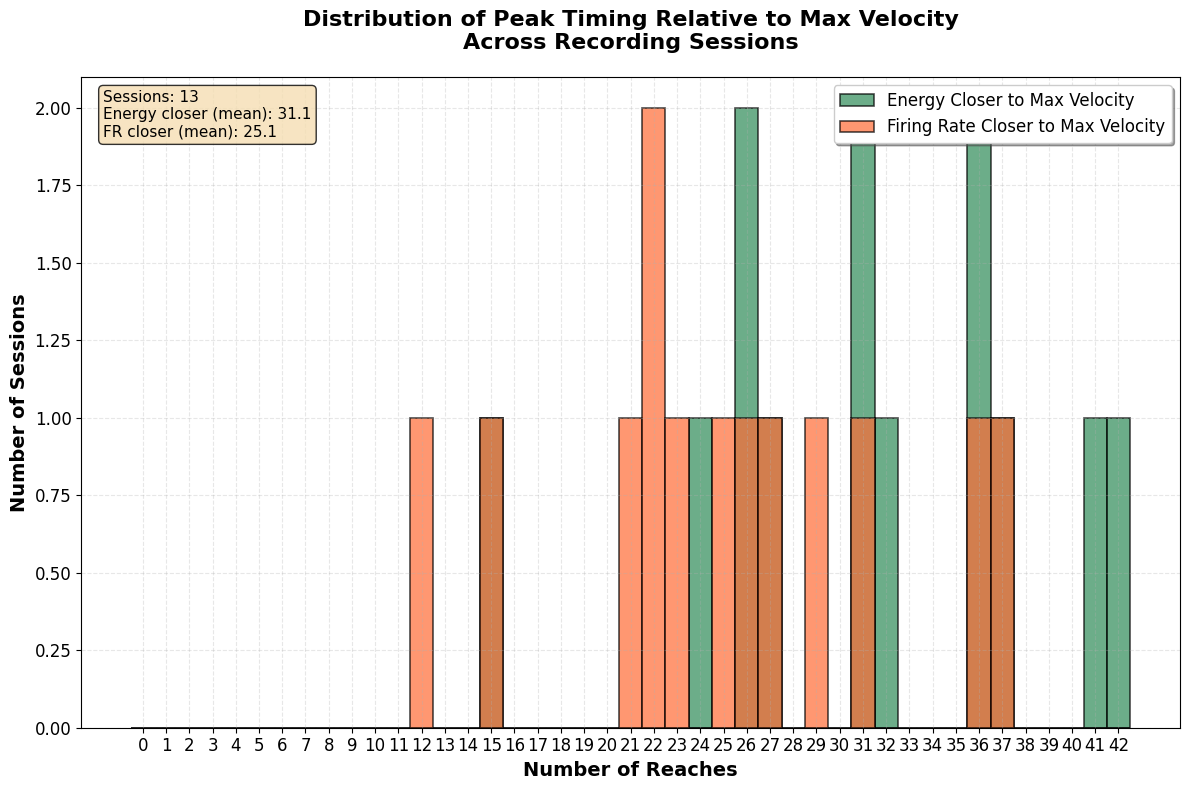

In [66]:
# Extract data for plotting
energy_closer_counts = df_session_score.loc['energy_closer'].to_list()
fr_closer_counts = df_session_score.loc['fr_closer'].to_list()

# Create figure with improved styling
plt.figure(figsize=(12, 8))

# Set up bins for consistent comparison
max_val = max(max(energy_closer_counts), max(fr_closer_counts))
bins = np.arange(0, max_val + 2, 1) - 0.5  # Center bins on integers

# Create histograms with transparency and improved styling
plt.hist(energy_closer_counts, bins=bins, alpha=0.7, label='Energy Closer to Max Velocity', 
         color='#2E8B57', edgecolor='black', linewidth=1.2)
plt.hist(fr_closer_counts, bins=bins, alpha=0.7, label='Firing Rate Closer to Max Velocity', 
         color='#FF6B35', edgecolor='black', linewidth=1.2)

# Improve the plot appearance
plt.xlabel('Number of Reaches', fontsize=14, fontweight='bold')
plt.ylabel('Number of Sessions', fontsize=14, fontweight='bold')
plt.title('Distribution of Peak Timing Relative to Max Velocity\nAcross Recording Sessions', 
          fontsize=16, fontweight='bold', pad=20)

# Add legend with better positioning
plt.legend(loc='upper right', frameon=True, fancybox=True, shadow=True, fontsize=12)

# Improve grid and ticks
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(range(0, max_val + 1), fontsize=12)
plt.yticks(fontsize=12)

# Add statistics text box
energy_mean = np.mean(energy_closer_counts)
fr_mean = np.mean(fr_closer_counts)
total_sessions = len(energy_closer_counts)

stats_text = f'Sessions: {total_sessions}\nEnergy closer (mean): {energy_mean:.1f}\nFR closer (mean): {fr_mean:.1f}'
plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
         fontsize=11)

# Tight layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()

# Optional: Save the figure
# plt.savefig('peak_timing_distribution.png', dpi=300, bbox_inches='tight')

In [ ]:
for key in list(per_reach.keys()):
    df = pd.DataFrame(per_reach[key])
    df.to_csv(f"{log_output}/{str(df.iloc[0]['mouse_id'])}/indvidual_reaches.csv")
    

In [45]:
str(pd.DataFrame(per_reach[key]).iloc[0]['mouse_id'])

'210423'

In [67]:
df_session_score['excluded_ratio'] = df_session_score['num_excluded']/df_session_score['num_reaches']

KeyError: 'num_excluded'

In [45]:
df_session_score_t = df_session_score.transpose()
df_session_score_t['excluded_ratio'] = df_session_score_t['num_excluded']/df_session_score_t['num_reaches']
df_session_score_t['energy_win_ratio'] = df_session_score_t['energy_closer']/df_session_score_t['num_reaches']

KeyError: 'num_excluded'

In [64]:
df_session_score_t

,0,1,2,3,4
Unnamed: 0,energy_closer,fr_closer,num_neurons,num_excluded,num_reaches
210423_fChR2,42,20,5,0,62
210425_fChR2,35,17,5,0,52
210511_fChR5,33,32,12,2,65
210512_fChR5,29,24,8,8,53
210514_fChR2,27,29,11,6,56
210515_fChR5,31,33,18,19,64
210606_fChR4,33,17,30,9,50
210614_fChR4,33,24,25,7,57
220515_DJC002,37,23,19,0,60


# Arbitration test

In [68]:
def create_arbitration_report(results, firing_gradient, sessions_score, per_reach, n_permutations=1000):
    """
    Create a comprehensive report with:
    1. Arbitration results (which metric wins per reach)
    2. Shuffle test (is the pattern real or random)
    """
    
    print("=" * 60)
    print("COMPREHENSIVE ARBITRATION REPORT")
    print("=" * 60)
    print()
    
    # Part 1: Compute arbitration results
    print("Part 1: Computing arbitration results (which metric wins)...")
    arbitration_results = {}
    reach_details = {}
    
    for idx, r in enumerate(results):
        if idx % 50 == 0:
            print(f"  Processing reach {idx}/{len(results)}")
        
        unique_idx = f"{r['mouse_id']}_{r['stim']}-{r['reach_idx']}"
        try:
            f = firing_gradient.loc[firing_gradient['unique_idx'] == unique_idx].iloc[0]
        except:
            continue
        
        full_mouse_id = f['mouse_id']
        
        if full_mouse_id not in arbitration_results:
            arbitration_results[full_mouse_id] = {
                "energy_closer": 0,
                "fr_closer": 0,
                "total_reaches": 0,
                "num_neurons": f['num_neurons']
            }
            reach_details[full_mouse_id] = []
        
        # Calculate distances
        max_velocity = int(str(r['max_velocity_idx']).split(",")[0])
        gradient = f['firing_rate_gradient_velocity_max']
        
        if gradient < 0:
            energy_idx_str = r['min_energy_idx']
            fr_idx_str = r['max_fr_idx']
        else:
            energy_idx_str = r['max_energy_idx']
            fr_idx_str = r['min_fr_idx']
        
        energy_indices = [int(e) for e in energy_idx_str.split(",")]
        fr_indices = [int(fr) for fr in fr_idx_str.split(",")]
        
        energy_distances = [abs(e - max_velocity) for e in energy_indices]
        fr_distances = [abs(fr - max_velocity) for fr in fr_indices]
        
        min_energy_dist = min(energy_distances)
        min_fr_dist = min(fr_distances)
        
        energy_wins = min_energy_dist < min_fr_dist
        
        arbitration_results[full_mouse_id]['total_reaches'] += 1
        if energy_wins:
            arbitration_results[full_mouse_id]['energy_closer'] += 1
        else:
            arbitration_results[full_mouse_id]['fr_closer'] += 1
        
        # Store reach details
        reach_details[full_mouse_id].append({
            'reach_idx': r['reach_idx'],
            'stim': r['stim'],
            'energy_wins': energy_wins,
            'energy_distance': min_energy_dist,
            'fr_distance': min_fr_dist,
            'gradient': gradient
        })
    
    print(f"\nPart 1 complete. Processed {len(arbitration_results)} mice\n")
    
    # Part 2: Run shuffle test
    print(f"Part 2: Running shuffle test ({n_permutations} permutations)...\n")
    
    final_results = {}
    
    for mouse_idx, full_mouse_id in enumerate(arbitration_results.keys()):
        print(f"Processing mouse {mouse_idx + 1}/{len(arbitration_results)}: {full_mouse_id}")
        
        # Get this mouse's data
        mouse_date = full_mouse_id.split('_')[0]
        mouse_reaches = []
        mouse_firing = []
        
        for r in results:
            if str(r['mouse_id']) == mouse_date:
                unique_idx = f"{r['mouse_id']}_{r['stim']}-{r['reach_idx']}"
                try:
                    f = firing_gradient.loc[firing_gradient['unique_idx'] == unique_idx].iloc[0]
                    if f['mouse_id'] == full_mouse_id:
                        mouse_reaches.append(r)
                        mouse_firing.append(f)
                except:
                    continue
        
        print(f"  Found {len(mouse_reaches)} reaches")
        
        if len(mouse_reaches) == 0:
            continue
        
        # Extract measurements
        all_energy_measurements = []
        all_fr_measurements = []
        all_max_velocities = []
        
        for r, f in zip(mouse_reaches, mouse_firing):
            max_velocity = int(str(r['max_velocity_idx']).split(",")[0])
            gradient = f['firing_rate_gradient_velocity_max']
            
            all_max_velocities.append(max_velocity)
            
            if gradient < 0:
                all_energy_measurements.append(r['min_energy_idx'])
                all_fr_measurements.append(r['max_fr_idx'])
            else:
                all_energy_measurements.append(r['max_energy_idx'])
                all_fr_measurements.append(r['min_fr_idx'])
        
        # Run permutations
        null_distribution = []
        
        print(f"  Running permutations: ", end='', flush=True)
        for perm in range(n_permutations):
            if perm % 100 == 0:
                print(f"{perm}...", end='', flush=True)
            
            shuffled_energy = np.random.permutation(all_energy_measurements)
            energy_wins = 0
            
            for i in range(len(all_energy_measurements)):
                max_vel = all_max_velocities[i]
                energy_indices = [int(e) for e in shuffled_energy[i].split(",")]
                fr_indices = [int(fr) for fr in all_fr_measurements[i].split(",")]
                
                energy_distances = [abs(e - max_vel) for e in energy_indices]
                fr_distances = [abs(fr - max_vel) for fr in fr_indices]
                
                if min(energy_distances) < min(fr_distances):
                    energy_wins += 1
            
            null_distribution.append(energy_wins)
        
        print(" Done!")
        
        null_distribution = np.array(null_distribution)
        
        arb_energy_wins = arbitration_results[full_mouse_id]['energy_closer']
        arb_fr_wins = arbitration_results[full_mouse_id]['fr_closer']
        arb_total = arbitration_results[full_mouse_id]['total_reaches']
        
        p_value = np.sum(null_distribution >= arb_energy_wins) / n_permutations
        
        final_results[full_mouse_id] = {
            # ARBITRATION RESULTS (which metric actually wins)
            'arbitration_energy_wins': arb_energy_wins,
            'arbitration_fr_wins': arb_fr_wins,
            'arbitration_total_reaches': arb_total,
            'arbitration_energy_proportion': arb_energy_wins / arb_total if arb_total > 0 else 0,
            'num_neurons': arbitration_results[full_mouse_id]['num_neurons'],
            
            # SHUFFLE TEST RESULTS (is the pattern real?)
            'shuffle_mean_energy_wins': np.mean(null_distribution),
            'shuffle_std_energy_wins': np.std(null_distribution),
            'shuffle_expected_proportion': np.mean(null_distribution) / arb_total if arb_total > 0 else 0,
            'shuffle_p_value': p_value,
            'shuffle_significant': p_value < 0.05,
            
            # EFFECT SIZE (how strong is the pattern?)
            'effect_size': (arb_energy_wins / arb_total - 0.5) if arb_total > 0 else 0
        }
        
        print(f"  Results:")
        print(f"    Arbitration: Energy wins {arb_energy_wins}/{arb_total} ({arb_energy_wins/arb_total*100:.1f}%)")
        print(f"    Shuffle null: Energy wins {np.mean(null_distribution):.1f}/{arb_total} ({np.mean(null_distribution)/arb_total*100:.1f}%)")
        print(f"    P-value: {p_value:.4f} {'***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'n.s.'}")
        print()
    
    # Create summary
    print("=" * 60)
    print("SUMMARY TABLE")
    print("=" * 60)
    
    df_results = pd.DataFrame(final_results).T
    df_results = df_results.sort_values('shuffle_p_value')
    
    print("\nFull Results:")
    print(df_results.to_string())
    
    # Count significant results
    n_significant = df_results['shuffle_significant'].sum()
    n_total = len(df_results)
    
    print("\n" + "=" * 60)
    print("INTERPRETATION")
    print("=" * 60)
    print(f"\n{n_significant}/{n_total} mice show significant energy preference (p < 0.05)")
    
    if n_significant > 0:
        print(f"\nMice with significant results:")
        sig_mice = df_results[df_results['shuffle_significant']]
        for mouse_id, row in sig_mice.iterrows():
            print(f"  {mouse_id}: {row['arbitration_energy_wins']}/{row['arbitration_total_reaches']} ({row['arbitration_energy_proportion']*100:.1f}%), p={row['shuffle_p_value']:.4f}")
    
    # Overall aggregate test using binomial distribution
    from scipy import stats
    total_energy = df_results['arbitration_energy_wins'].sum()
    total_reaches = df_results['arbitration_total_reaches'].sum()
    
    print(f"\nAGGREGATE across all mice:")
    print(f"  Arbitration: Energy wins {total_energy}/{total_reaches} ({total_energy/total_reaches*100:.1f}%)")
    print(f"  Expected by chance: ~{total_reaches/2:.0f}/{total_reaches} (50%)")
    
    # Use binomtest (new version) instead of binom_test (deprecated)
    binom_result = stats.binomtest(int(total_energy), int(total_reaches), 0.5, alternative='two-sided')
    binom_p = binom_result.pvalue
    print(f"  Binomial test p-value: {binom_p:.4f} {'***' if binom_p < 0.001 else '**' if binom_p < 0.01 else '*' if binom_p < 0.05 else 'n.s.'}")
    
    return df_results, reach_details


# Run the full analysis
df_full_report, reach_details = create_arbitration_report(
    results, 
    firing_gradient, 
    df_session_score, 
    per_reach, 
    n_permutations=1000
)

# Save results
df_full_report.to_csv(f"/data001/projects/ising/energy_decomposition_outputs/{username}/hand_review/closest_point/shuffle_test_results_flipped.csv")

COMPREHENSIVE ARBITRATION REPORT

Part 1: Computing arbitration results (which metric wins)...
  Processing reach 0/730
  Processing reach 50/730
  Processing reach 100/730
  Processing reach 150/730
  Processing reach 200/730
  Processing reach 250/730
  Processing reach 300/730
  Processing reach 350/730
  Processing reach 400/730
  Processing reach 450/730
  Processing reach 500/730
  Processing reach 550/730
  Processing reach 600/730
  Processing reach 650/730
  Processing reach 700/730

Part 1 complete. Processed 13 mice

Part 2: Running shuffle test (1000 permutations)...

Processing mouse 1/13: 210423_fChR2
  Found 62 reaches
0...100...200...300...400...500...600...700...800...900... Done!
  Results:
    Arbitration: Energy wins 26/62 (41.9%)
    Shuffle null: Energy wins 28.2/62 (45.5%)
    P-value: 0.8720 n.s.

Processing mouse 2/13: 210425_fChR2
  Found 52 reaches
0...100...200...300...400...500...600...700...800...900... Done!
  Results:
    Arbitration: Energy wins 15/52 (

In [54]:
df_shuffle_results = pd.read_csv(f"/data001/projects/ising/energy_decomposition_outputs/{username}/hand_review/closest_point/shuffle_test_results.csv")

In [31]:
# Extract data for plotting
energy_closer_counts = df_shuffle_results.loc['energy_closer'].to_list()
fr_closer_counts = df_shuffle_results.loc['fr_closer'].to_list()

# Create figure with improved styling
plt.figure(figsize=(12, 8))

# Set up bins for consistent comparison
max_val = max(max(energy_closer_counts), max(fr_closer_counts))
bins = np.arange(0, max_val + 2, 1) - 0.5  # Center bins on integers

# Create histograms with transparency and improved styling
plt.hist(energy_closer_counts, bins=bins, alpha=0.7, label='Energy Closer to Max Velocity', 
         color='#2E8B57', edgecolor='black', linewidth=1.2)
plt.hist(fr_closer_counts, bins=bins, alpha=0.7, label='Firing Rate Closer to Max Velocity', 
         color='#FF6B35', edgecolor='black', linewidth=1.2)

# Improve the plot appearance
plt.xlabel('Number of Reaches', fontsize=14, fontweight='bold')
plt.ylabel('Number of Sessions', fontsize=14, fontweight='bold')
plt.title('Distribution of Peak Timing Relative to Max Velocity\nAcross Recording Sessions', 
          fontsize=16, fontweight='bold', pad=20)

# Add legend with better positioning
plt.legend(loc='upper right', frameon=True, fancybox=True, shadow=True, fontsize=12)

# Improve grid and ticks
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(range(0, max_val + 1), fontsize=12)
plt.yticks(fontsize=12)

# Add statistics text box
energy_mean = np.mean(energy_closer_counts)
fr_mean = np.mean(fr_closer_counts)
total_sessions = len(energy_closer_counts)

stats_text = f'Sessions: {total_sessions}\nEnergy closer (mean): {energy_mean:.1f}\nFR closer (mean): {fr_mean:.1f}'
plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
         fontsize=11)

# Tight layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()

# Optional: Save the figure
# plt.savefig('peak_timing_distribution.png', dpi=300, bbox_inches='tight')

KeyError: 'energy_closer'

In [59]:
df_full_report # FR gradient not inverted

,arbitration_energy_wins,arbitration_fr_wins,arbitration_total_reaches,arbitration_energy_proportion,num_neurons,shuffle_mean_energy_wins,shuffle_std_energy_wins,shuffle_expected_proportion,shuffle_p_value,shuffle_significant,effect_size
220515_DJC002,37,23,60,0.616667,19,32.386,2.339873,0.539767,0.041,True,0.116667
210515_fChR5,31,33,64,0.484375,18,28.048,2.546703,0.43825,0.172,False,-0.015625
210614_fChR4,33,24,57,0.578947,25,30.856,2.26964,0.541333,0.219,False,0.078947
210423_fChR2,42,20,62,0.677419,5,40.89,2.46534,0.659516,0.396,False,0.177419
220517_DJC002,28,26,54,0.518519,24,27.446,2.205694,0.508259,0.486,False,0.018519
220516_DJC000,33,18,51,0.647059,19,32.668,2.028245,0.640549,0.52,False,0.147059
210511_fChR5,33,32,65,0.507692,12,33.387,2.638414,0.513646,0.646,False,0.007692
210512_fChR5,29,24,53,0.54717,8,29.498,2.090932,0.556566,0.676,False,0.04717
220520_DJC000,32,22,54,0.592593,27,32.742,2.450599,0.606333,0.698,False,0.092593
210606_fChR4,33,17,50,0.66,30,33.596,2.084415,0.67192,0.706,False,0.16


In [8]:
pd.read_csv(f"/data001/projects/ising/energy_decomposition_outputs/{username}/hand_review/closest_point/shuffle_test_results.csv")

,Unnamed: 0


In [69]:
df_full_report # FR gradient inverted

,arbitration_energy_wins,arbitration_fr_wins,arbitration_total_reaches,arbitration_energy_proportion,num_neurons,shuffle_mean_energy_wins,shuffle_std_energy_wins,shuffle_expected_proportion,shuffle_p_value,shuffle_significant,effect_size
210512_fChR5,41,12,53,0.773585,8,34.102,2.04978,0.643434,0.0,True,0.273585
220516_DJC000,36,15,51,0.705882,19,30.768,1.869272,0.603294,0.006,True,0.205882
220518_DJC000,31,21,52,0.596154,27,29.258,2.102245,0.562654,0.27,False,0.096154
210514_fChR2,31,25,56,0.553571,11,29.38,2.199454,0.524643,0.295,False,0.053571
210515_fChR5,42,22,64,0.65625,18,40.407,2.548598,0.631359,0.323,False,0.15625
220520_DJC000,27,27,54,0.5,27,25.643,2.606828,0.47487,0.351,False,0.0
210614_fChR4,26,31,57,0.45614,25,25.024,2.292907,0.439018,0.416,False,-0.04386
210511_fChR5,36,29,65,0.553846,12,35.802,2.53235,0.5508,0.551,False,0.053846
210606_fChR4,24,26,50,0.48,30,23.9,2.074608,0.478,0.569,False,-0.02
220515_DJC002,37,23,60,0.616667,19,37.683,2.169449,0.62805,0.704,False,0.116667
